# Imports

In [ ]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm
from PIL import Image
from typing import Any, Callable, Dict , List, Optional, Tuple

# Config

In [31]:
config = {
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "data_directory": "../data",
    "model_directory": "../models",
    "representation_model_name": "simclr_dev.pth"
}

augmentation_config = {
    "size": 32,
    "scale": (0.2, 1.0),
    "p_random_horizontal_flip": 0.5,
    "brightness": 0.4,
    "contrast": 0.4,
    "saturation": 0.4,
    "hue": 0.1,
    "p_color_jitter": 0.8,
    "p_grayscale": 0.2,
    "mean": (0.4914, 0.4822, 0.4465),
    "std": (0.2023, 0.1994, 0.2010),
}

training_config = {
    "epochs": 20,        # Paper uses 500; set higher for real runs.
    "batch_size": 128,   # Paper uses 512.
    "lr": 0.4,
    "momentum": 0.9,
    "weight_decay": 0.0001,
}

cluster_config = {
    "max_clusters": 500,  # Paper uses 500 for CIFAR-10/100 (Appendix F.1).
    "B": 10,              # Budget per round. B = M (10 classes) matches paper.
    "min_cluster_size": 5,  # Drop clusters smaller than this (Appendix F.1).
}

# Reproducibility

In [32]:
def set_seed(seed: int) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(config["seed"])

# Data Augmentation

In [ ]:
class StochasticDataAugmentation:

    def __init__(self, base_transform: transforms.Compose, num_views: int = 2) -> None:
        self.base_transform = base_transform
        self.num_views = num_views

    def __call__(self, x: torch.Tensor) -> List[torch.Tensor]:
        return [self.base_transform(x) for _ in range(self.num_views)]

contrastive_base_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        size=augmentation_config["size"],
        scale=augmentation_config["scale"],
    ),
    transforms.RandomHorizontalFlip(p=augmentation_config["p_random_horizontal_flip"]),
    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=augmentation_config["brightness"],
            contrast=augmentation_config["contrast"],
            saturation=augmentation_config["saturation"],
            hue=augmentation_config["hue"],
        ),
    ], p=augmentation_config["p_color_jitter"]),
    transforms.RandomGrayscale(p=augmentation_config["p_grayscale"]),
    transforms.ToTensor(),
    transforms.Normalize(mean=augmentation_config["mean"], std=augmentation_config["std"]),
])

contrastive_transform = StochasticDataAugmentation(contrastive_base_transform, num_views=2)

embedding_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=augmentation_config["mean"], std=augmentation_config["std"]),
])

# Dataset

In [ ]:
class SimCLRDataset(torch.utils.data.Dataset):
    def __init__(self, root: str, train: bool = True, download: bool = True, transform: Optional[Callable] = None, num_views: int = 2) -> None:
        self.dataset = torchvision.datasets.CIFAR10(root=root, train=train, download=download)
        self.transform = transform
        self.num_views = num_views

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, int]:
        image, label = self.dataset[index]
        if not isinstance(image, Image.Image):
            image = Image.fromarray(image)
        views = [self.transform(image) for _ in range(self.num_views)]
        return views, label

# SimCLR Model

In [35]:
class SimCLRModel(nn.Module):

    def __init__(self, feature_dimension: int = 128) -> None:
        super().__init__()
        self.base_encoder = torchvision.models.resnet18(weights=None)
        in_features = self.base_encoder.fc.in_features
        self.base_encoder.fc = nn.Identity()

        self.mlp = nn.Sequential(
            nn.Linear(in_features, in_features),
            nn.ReLU(),
            nn.Linear(in_features, feature_dimension),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.mlp(self.base_encoder(x))

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            return F.normalize(self.base_encoder(x), p=2, dim=1)


# SimCLR Loss (NT-Xent)

In [ ]:
class SimCLRLoss(nn.Module):

    def __init__(self, temperature: float = 0.5) -> None:
        super().__init__()
        self.temperature = temperature

    def forward(self, z_i: torch.Tensor, z_j: torch.Tensor) -> torch.Tensor:
        N = z_i.size(0)
        z = F.normalize(torch.cat([z_i, z_j], dim=0), p=2, dim=1)

        # Cosine similarity matrix scaled by temperature
        sim = torch.matmul(z, z.T) / self.temperature
        # Mask diagonal (self-similarity) with a large negative value
        sim.masked_fill_(torch.eye(2 * N, device=z.device).bool(), -1e9)

        # Positive for index k is index k+N (and vice-versa)
        labels = (torch.arange(2 * N, device=z.device) + N) % (2 * N)
        return F.cross_entropy(sim, labels)

# Training Helpers

In [37]:
def similarity_statistics(z_i: torch.Tensor, z_j: torch.Tensor) -> tuple:
    with torch.no_grad():
        N = z_i.size(0)
        z = F.normalize(torch.cat([z_i, z_j], dim=0), dim=1)
        sim = torch.matmul(z, z.T)

        positives = torch.cat([torch.diag(sim, N), torch.diag(sim, -N)])
        mask = torch.eye(2 * N, device=z.device).bool()
        negatives = sim[~mask].view(2 * N, -1)

        return positives.mean().item(), negatives.mean().item()

# SimCLR Training (Step 1 of TPC_RP: Representation Learning)

In [38]:
device = torch.device(config["device"])
print(f"Using device: {device}")

model = SimCLRModel().to(device)
optimizer = optim.SGD(
    model.parameters(),
    lr=training_config["lr"],
    momentum=training_config["momentum"],
    weight_decay=training_config["weight_decay"],
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=training_config["epochs"],
    eta_min=0,
)
criterion = SimCLRLoss()

train_dataset = SimCLRDataset(
    root=config["data_directory"],
    train=True,
    transform=contrastive_base_transform,
    num_views=2
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=training_config["batch_size"],
    shuffle=True,
    num_workers=2,
    persistent_workers=True,
    pin_memory=True,
    drop_last=True,
)

for epoch in range(training_config["epochs"]):
    model.train()
    total_loss = total_positive_similarity = total_negative_similarity = 0.0

    for views, _ in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{training_config['epochs']}"):
        x_i, x_j = views[0].to(device), views[1].to(device)
        z_i, z_j = model(x_i), model(x_j)

        positive_similarity, negative_similarity = similarity_statistics(z_i, z_j)
        loss = criterion(z_i, z_j)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_positive_similarity += positive_similarity
        total_negative_similarity += negative_similarity

    scheduler.step()
    n = len(train_loader)
    print(
        f"Loss: {total_loss / n:7.4f} | "
        f"Positive-Similarity: {total_positive_similarity / n:6.3f} | "
        f"Negative-Similarity: {total_negative_similarity / n:6.3f} | "
        f"LR: {scheduler.get_last_lr()[0]:.6f}"
    )

torch.save(model.state_dict(), str(config["model_directory"] + "/" + config["representation_model_name"]))

Using device: cuda
Files already downloaded and verified


Epoch 1/20: 100%|██████████| 390/390 [01:13<00:00,  5.33it/s]


Loss:  4.7453 | Positive-Similarity:  0.652 | Negative-Similarity:  0.020 | LR: 0.397538


Epoch 2/20: 100%|██████████| 390/390 [01:10<00:00,  5.53it/s]


Loss:  4.5798 | Positive-Similarity:  0.695 | Negative-Similarity:  0.004 | LR: 0.390211


...

Loss:  4.1465 | Positive-Similarity:  0.810 | Negative-Similarity: -0.003 | LR: 0.009789


Epoch 19/20: 100%|██████████| 390/390 [01:09<00:00,  5.61it/s]


Loss:  4.1396 | Positive-Similarity:  0.812 | Negative-Similarity: -0.003 | LR: 0.002462


Epoch 20/20: 100%|██████████| 390/390 [01:09<00:00,  5.60it/s]


Loss:  4.1333 | Positive-Similarity:  0.815 | Negative-Similarity: -0.003 | LR: 0.000000


# Build Embeddings (L2-Normalised penultimate layer, 512-d)

In [39]:
model.load_state_dict(torch.load(str(config["model_directory"] + "/" + config["representation_model_name"])))
model.eval()

embedding_dataset = torchvision.datasets.CIFAR10(
    root=config["data_directory"], train=True, download=True, transform=embedding_transform
)
embedding_loader = torch.utils.data.DataLoader(
    embedding_dataset,
    batch_size=training_config["batch_size"],
    shuffle=False,
    num_workers=2,
    persistent_workers=True,
    pin_memory=True,
    drop_last=False,
)

all_embeddings_list, all_labels_list = [], []
with torch.no_grad():
    for images, labels in tqdm(embedding_loader, desc="Embedding dataset"):
        all_embeddings_list.append(model.encode(images.to(device)).cpu())
        all_labels_list.append(labels)

all_embeddings = torch.cat(all_embeddings_list).numpy()
all_labels = torch.cat(all_labels_list).numpy()
print(f"Embeddings: {all_embeddings.shape}, Labels: {all_labels.shape}")

Files already downloaded and verified


Embedding dataset: 100%|██████████| 391/391 [00:07<00:00, 55.15it/s]


Embeddings: (50000, 512), Labels: (50000,)


# Baseline AL Strategies

In [ ]:
from abc import ABC, abstractmethod

class Strategy(ABC):

    @abstractmethod
    def query(self, state: Dict[str, Any], budget: int) -> List[int]:
        pass

## 1. Random
Selects data points entirely at random, with no consideration of model uncertainty or diversity

In [ ]:
class RandomStrategy(Strategy):

    def query(self, state: Dict[str, Any], budget: int) -> List[int]:
        dataset = state["dataset"]
        labeled = state["labeled"]

        pool = list(set(range(len(dataset))) - labeled)

        return random.sample(pool, budget)


## 2. Uncertainy
Chooses samples the mode is least confident about to improve learning efficiency

In [42]:
def get_softmax_scores(
    model: nn.Module,
    dataset: torch.utils.data.Dataset,
    indices: list,
    device: torch.device,
) -> np.ndarray:
    subset = torch.utils.data.Subset(dataset, indices)
    loader = torch.utils.data.DataLoader(subset, batch_size=256, shuffle=False, num_workers=2)
    model.eval()
    probabilities = []
    with torch.no_grad():
        for images, _ in loader:
            probabilities.append(F.softmax(model(images.to(device)), dim=1).cpu().numpy())
    return np.concatenate(probabilities, axis=0)

In [ ]:
class UncertaintyStrategy(Strategy):

    def query(self, state: Dict[str, Any], budget: int) -> List[int]:

        model = state["model"]
        dataset = state["dataset"]
        labeled = state["labeled"]

        pool = list(set(range(len(dataset))) - labeled)
        probabilities = get_softmax_scores(model, dataset, pool, device)
        max_probabilities = probabilities.max(axis=1)
        chosen = np.argsort(max_probabilities)[:budget]

        return [pool[index] for index in chosen]

## 3. Margin
Selects examples where the difference between the top predicted classes is smallest, indicating ambiguity

In [ ]:
class MarginStrategy(Strategy):

    def query(self, state: Dict[str, Any], budget: int) -> List[int]:

        model = state["model"]
        dataset = state["dataset"]
        labeled = state["labeled"]

        pool = list(set(range(len(dataset))) - labeled)
        probabilities = get_softmax_scores(model, dataset, pool, device)
        sorted_probabilities = np.sort(probabilities, axis=1)
        margins = sorted_probabilities[:, -1] - sorted_probabilities[:, -2]
        chosen = np.argsort(margins)[:budget]

        return [pool[index] for index in chosen]

## 4. Entropy
Picks samples with the highest prediction uncertainty, measured by the entropy of the model's output distribution

In [ ]:
class EntropyStrategy(Strategy):

    def query(self, state: Dict[str, Any], budget: int) -> List[int]:

        model = state["model"]
        dataset = state["dataset"]
        labeled = state["labeled"]

        pool = list(set(range(len(dataset))) - labeled)
        probabilities = get_softmax_scores(model, dataset, pool, device)
        entropy = -np.sum(probabilities * np.log(probabilities + 1e-12), axis=1)
        chosen = np.argsort(-entropy)[:budget]

        return [pool[index] for index in chosen]

## 5. DBAL — Deep Bayesian Active Learning (Gal et al. 2017)
Uses Monte Carlo simulations to estimate prediction uncertainty and select the most informative samples


In [ ]:
def get_dropout_predictions(
    model: nn.Module,
    dataset: torch.utils.data.Dataset,
    indices: list,
    device: torch.device,
    passes: int = 10,
    batch_size: int = 256
) -> np.ndarray:
    # Enable Monte Carlo Dropout
    model.train()
    loader = torch.utils.data.DataLoader(
        torch.utils.data.Subset(dataset, indices),
        batch_size=batch_size,
        shuffle=False
    )
    all_probabilities = []

    # Run T stochastic forward passes (Approximates q*_{theta}(w))
    for _ in range(passes):
        probabilities_list = []
        with torch.no_grad():
            for x, _ in loader:
                x = x.to(device)
                logits = model(x)
                probabilities = torch.softmax(logits, dim=1)
                probabilities_list.append(probabilities.cpu().numpy())

        all_probabilities.append(np.concatenate(probabilities_list))

    # Returns all T stochastic forward passes (\hat{p}^t_c)
    return np.stack(all_probabilities)

In [ ]:
class DBALStrategy(Strategy):

    def query(self, state: Dict[str, Any], budget: int) -> List[int]:
        model   = state["model"]
        dataset = state["dataset"]
        labeled = state["labeled"]

        pool = list(set(range(len(dataset))) - labeled)
        predictions = get_dropout_predictions(model, dataset, pool, device)

        # p(y=c | x, D_train) ≈ 1/T ∑_t p̂^t_c
        mean_probabilities = predictions.mean(axis=0)

        # Max Entropy: H[y | x, D_train]
        entropy = -np.sum(mean_probabilities * np.log(mean_probabilities + 1e-12), axis=1)

        chosen = np.argsort(-entropy)[:budget]
        return [pool[index] for index in chosen]

## 6. CoreSet (Sener & Savarese 2018)
Chooses a diverse subset of the data that best represents the overall dataset using geometric coverage.

In [ ]:
class CoreSetStrategy(Strategy):

    def query(self, state: Dict[str, Any], budget: int) -> List[int]:

        embeddings = state["embeddings"]
        labeled = list(state["labeled"])
        unlabeled = list(set(range(len(embeddings))) - set(labeled))

        labeled_embeddings = embeddings[labeled]
        unlabeled_embeddings = embeddings[unlabeled]

        # Initialize min distances for each unlabelled point to the nearest labeled point
        # min_{j \in s^0} \Delta(xi, xj) for all i \in [n]\s^0
        min_distances = pairwise_distances(
            unlabeled_embeddings, 
            labeled_embeddings
        ).min(axis=1)

        chosen_indices = []

        for _ in range(budget):
            # Picks unlabelled point with largest distance to nearest labeled point
            # u = argmax_{i \in [n]\s} min_{j \in s} \Delta(xi, xj)
            best = np.argmax(min_distances)
            chosen_indices.append(best) # s = s \cup {u}

            # Ensures next iteration treats x_u as part of s
            # min_{j \in s} \Delta(xi, xj) = min(prev distance, \Delta(xi, x_u))
            new_distances = pairwise_distances(
                unlabeled_embeddings,
                unlabeled_embeddings[best].reshape(1, -1)
            ).flatten()
            min_distances = np.minimum(min_distances, new_distances)

        return [unlabeled[index] for index in chosen_indices]

## 7. BALD — Bayesian Active Learning by Disagreement (Kirsch et al. 2019)
Selects samples that maximize the expected information gain about the model parameters.

In [ ]:
class BALDStrategy(Strategy):

    def query(self, state: Dict[str, Any], budget: int) -> List[int]:

        model = state["model"]
        dataset = state["dataset"]
        labeled = state["labeled"]

        pool = list(set(range(len(dataset))) - labeled)
        predictions = get_dropout_predictions(model, dataset, pool, device)

        mean_probabilities = predictions.mean(axis=0)
        entropy_mean = -np.sum(mean_probabilities * np.log(mean_probabilities + 1e-12), axis=1)
        entropy_samples = -np.sum(predictions * np.log(predictions + 1e-12), axis=2)
        
        mean_entropy = entropy_samples.mean(axis=0)
        bald_score = entropy_mean - mean_entropy
        chosen = np.argsort(-bald_score)[:budget]

        return [pool[index] for index in chosen]

 ## 8. BADGE — Batch Active learning by Diverse Gradient Embeddings (Ash et al. 2020)
Selects samples whose gradients would most change the model parameters while ensuring diversity.

In [ ]:
def get_gradient_embeddings(
    model: nn.Module,
    dataset: torch.utils.data.Dataset,
    indices: list,
    device: torch.device,
    batch_size: int = 256
) -> np.ndarray:

    model.eval()

    loader = torch.utils.data.DataLoader(
        torch.utils.data.Subset(dataset, indices),
        batch_size=batch_size,
        shuffle=False
    )

    penultimate_features = {}
    def hook_fn(module, input, output):
        penultimate_features["features"] = input[0].detach()
    
    final_linear = [m for m in model.modules() if isinstance(m, torch.nn.Linear)][-1]
    hook = final_linear.register_forward_hook(hook_fn)

    embeddings = []

    with torch.no_grad():

        for x, _ in loader:

            x = x.to(device)

            logits = model(x)

            probabilities = torch.softmax(logits, dim=1)

            predictions = probabilities.argmax(dim=1)

            one_hot = torch.zeros_like(probabilities)
            one_hot.scatter_(1, predictions.unsqueeze(1), 1)

            gradient = probabilities - one_hot

            features = penultimate_features["features"]

            gradient_embeddings = torch.einsum("bi,bj->bij", gradient, features)
            gradient_embeddings = gradient_embeddings.reshape(gradient_embeddings.size(0), -1)
            embeddings.append(gradient_embeddings.cpu().numpy())

    hook.remove()
    return np.concatenate(embeddings)

def kmeans_plusplus_seeding(
    embeddings: np.ndarray,
    budget: int
) -> List[int]:
    n = len(embeddings)
    first = np.random.randint(n)
    centers = [first]

    for _ in range(budget - 1):
        distances = pairwise_distances(embeddings, embeddings[centers])
        min_distances = distances.min(axis=1) ** 2

        probabilities = min_distances / min_distances.sum()
        next_center = np.random.choice(n, p=probabilities)
        centers.append(next_center)

    return centers

In [ ]:
class BADGEStrategy(Strategy):

    def query(self, state: Dict[str, Any], budget: int) -> List[int]:

        model = state["model"]
        dataset = state["dataset"]
        labeled = state["labeled"]

        pool = list(set(range(len(dataset))) - labeled)

        gradient_embeddings = get_gradient_embeddings(
            model,
            dataset,
            pool,
            device
        )

        chosen = kmeans_plusplus_seeding(gradient_embeddings, budget)
        return [pool[index] for index in chosen]

# TPC_RP AL Strategy

In [ ]:
class TypiclustStrategy(Strategy):
    def __init__(self, max_clusters: int = 500, min_cluster_size: int = 5):
        self.max_clusters = max_clusters
        self.min_cluster_size = min_cluster_size

    def compute_typicality(self, cluster_embeddings: np.ndarray, K: int = 20) -> np.ndarray:
        cluster_size = cluster_embeddings.shape[0]
        K = min(K, cluster_size - 1)
        if K <= 0:
            return np.ones(cluster_size, dtype=float)

        nn_model = NearestNeighbors(n_neighbors=K + 1, metric="euclidean")
        nn_model.fit(cluster_embeddings)
        distances, _ = nn_model.kneighbors(cluster_embeddings)

        mean_dist = np.mean(distances[:, 1:], axis=1)  # Exclude self-distance
        return 1.0 / (mean_dist + 1e-8)

    def get_clustering_model(self, n_clusters: int):
        if n_clusters <= 50:
            return KMeans(n_clusters=n_clusters, n_init=10, random_state=config["seed"])
        return MiniBatchKMeans(n_clusters=n_clusters, batch_size=1024, n_init=10, random_state=config["seed"])

    def eligible_clusters(
        self,
        cluster_labels: np.ndarray,
        labeled_set: set
    ) -> List[int]:

        cluster_ids = np.unique(cluster_labels)
        cluster_sizes = {}
        cluster_labeled_counts = {}

        for cluster_id in cluster_ids:
            if cluster_id < 0:
                continue

            members = np.where(cluster_labels == cluster_id)[0]
            cluster_sizes[cluster_id] = len(members)
            cluster_labeled_counts[cluster_id] = np.sum(np.isin(members, list(labeled_set)))

        # Find clusters with the fewest labeled samples
        min_labeled = min(cluster_labeled_counts.values())

        eligible = [
            cluster_id for cluster_id in cluster_ids
            if cluster_id >= 0
            and cluster_labeled_counts[cluster_id] == min_labeled
            and cluster_sizes[cluster_id] >= self.min_cluster_size
        ]

        if not eligible:
            eligible = [
                cluster_id for cluster_id in cluster_ids
                if cluster_id >= 0 and cluster_labeled_counts[cluster_id] == min_labeled
            ]

        return eligible
    
    def select_largest_cluster(self, cluster_labels: np.ndarray, eligible: list) -> int:
        return max(eligible, key=lambda cluster: np.sum(cluster_labels == cluster))

    def query(self, state: Dict[str, Any], budget: int) -> List[int]:
        embeddings = state["embeddings"]
        labeled_set = state["labeled"]

        # Determine number of clusters (K)
        n_clusters = min(len(labeled_set) + budget, self.max_clusters)
        clustering_model = self.get_clustering_model(n_clusters)
        cluster_labels = clustering_model.fit_predict(embeddings)

        new_indices = []
        remaining = budget
        temp_labels = cluster_labels.copy()

        while remaining > 0:
            eligible = self.eligible_clusters(temp_labels, labeled_set)
            if not eligible:
                break

            selected_cluster = self.select_largest_cluster(temp_labels, eligible)
            
            cluster_indices = np.where(temp_labels == selected_cluster)[0]
            cluster_indices = [idx for idx in cluster_indices if idx not in labeled_set and idx not in new_indices]

            if len(cluster_indices) == 0:
                temp_labels[temp_labels == selected_cluster] = -1
                continue

            cluster_indices = np.array(cluster_indices)
            cluster_embeddings = embeddings[cluster_indices]

            # Pick the most typical sample
            typicality_scores = self.compute_typicality(cluster_embeddings, K=20)
            best_local_idx = np.argmax(typicality_scores)
            chosen_idx = int(cluster_indices[best_local_idx])

            new_indices.append(chosen_idx)
            remaining -= 1

        return new_indices

# Classifer Training & Evaluation

In [53]:
def build_resnet18_classifier(device: torch.device, num_classes: int = 10) -> nn.Module:
    classifier = torchvision.models.resnet18(weights=None)
    classifier.fc = nn.Linear(classifier.fc.in_features, num_classes)    
    return classifier.to(device)

In [54]:
def train_classifier(
    labeled_indices: list,
    train_dataset: torch.utils.data.Dataset,
    device: torch.device,
    epochs: int = 100,
    batch_size: int = 64,
    model_override: nn.Module = None
) -> nn.Module:

    classifier = model_override if model_override else build_resnet18_classifier(device=device)
    
    subset = torch.utils.data.Subset(train_dataset, labeled_indices)
    loader = torch.utils.data.DataLoader(
        subset,
        batch_size=min(batch_size, len(labeled_indices)),
        shuffle=True,
        num_workers=2,
        drop_last=False
    )

    optimizer = optim.SGD(
        classifier.parameters(),
        lr=0.025,
        momentum=0.9,
        weight_decay=5e-4,
        nesterov=True
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    classifier.train()
    for _ in range(epochs):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = F.cross_entropy(classifier(images), labels)
            loss.backward()
            optimizer.step()
        scheduler.step()

    return classifier

In [55]:
def evaluate_classifier(
    classifier: nn.Module,
    test_loader: torch.utils.data.DataLoader,
    device: torch.device
) -> float:
    classifier.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = classifier(images)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    return correct / total

# Active Learning Loop

In [56]:
def add_dropout_to_resnet(model: nn.Module, p: float = 0.5) -> nn.Module:
    for _, module in model.named_modules():
        if isinstance(module, nn.Sequential):
            for i, m in enumerate(module):
                if isinstance(m, nn.ReLU):
                    module[i] = nn.Sequential(m, nn.Dropout(p=p))
    return model

In [ ]:
NEEDS_MODEL = {"Uncertainty", "Margin", "Entropy", "DBAL", "BALD", "BADGE"}
NEEDS_DROPOUT = {"DBAL", "BALD"}
NEEDS_COLD_START = {"Uncertainty", "Margin", "Entropy", "DBAL", "BALD", "BADGE", "CoreSet"}

test_dataset = torchvision.datasets.CIFAR10(
    root=config["data_directory"], train=False, download=True, transform=embedding_transform
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=256, shuffle=False, num_workers=2
)
full_train_dataset = torchvision.datasets.CIFAR10(
    root=config["data_directory"], train=True, download=True, transform=embedding_transform
)

strategy_fns = {
    "TPC_RP": lambda: TypiclustStrategy(max_clusters=cluster_config["max_clusters"], min_cluster_size=cluster_config["min_cluster_size"]),
    "Random": RandomStrategy,
    "Uncertainty": UncertaintyStrategy,
    "Margin": MarginStrategy,
    "Entropy": EntropyStrategy,
    "DBAL": DBALStrategy,
    "CoreSet": CoreSetStrategy,
    "BALD": BALDStrategy,
    "BADGE": BADGEStrategy,
}

num_rounds = 5
num_repetitions = 10
B = cluster_config["B"]

# all_accs[name] is a list of num_repetitions lists, each of length num_rounds
all_accuracies = {name: [] for name in strategy_fns}

for repetition_idx in range(num_repetitions):
    print(f"\n{'='*50}")
    print(f"Repetition {repetition_idx + 1}/{num_repetitions}")
    print(f"{'='*50}")

    # Fresh strategies each repetition
    strategies = {name: fn() for name, fn in strategy_fns.items()}
    for strategy in strategies.values():
        strategy.labeled = set()
        strategy.accuracies = []

    for round_idx in range(num_rounds):
        print(f"\n=== Round {round_idx + 1}/{num_rounds} (B={B}) ===")

        for name, strategy in strategies.items():
            state = {
                "labeled": strategy.labeled,
                "dataset": full_train_dataset,
                "embeddings": all_embeddings,
                "model": None,
            }

            if name in NEEDS_COLD_START and len(strategy.labeled) == 0:
                new_indices = RandomStrategy().query(state, B)
            else:
                if name in NEEDS_MODEL:
                    model = torchvision.models.resnet18(weights=None)
                    model.fc = nn.Linear(model.fc.in_features, 10)
                    model = model.to(device)
                    if name in NEEDS_DROPOUT:
                        model = add_dropout_to_resnet(model)
                    state["model"] = train_classifier(
                        labeled_indices=list(strategy.labeled),
                        train_dataset=full_train_dataset,
                        device=device,
                        epochs=100,
                        model_override=model,
                    )
                new_indices = strategy.query(state, B)

            strategy.labeled.update(new_indices)

            eval_model = train_classifier(
                labeled_indices=list(strategy.labeled),
                train_dataset=full_train_dataset,
                device=device,
                epochs=100,
            )
            accuracy = evaluate_classifier(eval_model, test_loader, device)
            strategy.accuracies.append(accuracy)
            print(f"  {name:12s} | labeled={len(strategy.labeled):4d} | acc={accuracy:.4f}")

    for name, strategy in strategies.items():
        all_accuracies[name].append(strategy.accuracies)


print(f"\n{'='*50}")
print("Final Results (Mean + Standard Error over Repetitions)")
print(f"{'='*50}")
for name, accuracy in all_accuracies.items():
    accuracies = np.array(accuracy)
    means = accuracies.mean(axis=0)
    stderrs = accuracies.std(axis=0) / np.sqrt(num_repetitions)
    print(f"\n  {name}")
    for r, (m, se) in enumerate(zip(means, stderrs)):
        print(f"    Round {r+1}: {m:.4f} + {se:.4f}")

Files already downloaded and verified
Files already downloaded and verified

Repetition 1/10

=== Round 1/5 (B=10) ===
  TPC_RP       | labeled=  10 | acc=0.1270
  Random       | labeled=  10 | acc=0.1679
  Uncertainty  | labeled=  10 | acc=0.1450
  Margin       | labeled=  10 | acc=0.1317
  Entropy      | labeled=  10 | acc=0.1302
  DBAL         | labeled=  10 | acc=0.1330
  CoreSet      | labeled=  10 | acc=0.1382
  BALD         | labeled=  10 | acc=0.1172
  BADGE        | labeled=  10 | acc=0.1419

=== Round 2/5 (B=10) ===
  TPC_RP       | labeled=  20 | acc=0.1775
  Random       | labeled=  20 | acc=0.1664
  Uncertainty  | labeled=  20 | acc=0.1510
  Margin       | labeled=  20 | acc=0.1405
  Entropy      | labeled=  20 | acc=0.1250
  DBAL         | labeled=  20 | acc=0.1579
  CoreSet      | labeled=  20 | acc=0.1452
  BALD         | labeled=  20 | acc=0.1258
  BADGE        | labeled=  20 | acc=0.1314

=== Round 3/5 (B=10) ===
  TPC_RP       | labeled=  30 | acc=0.1748
  Random    

# Plot Results

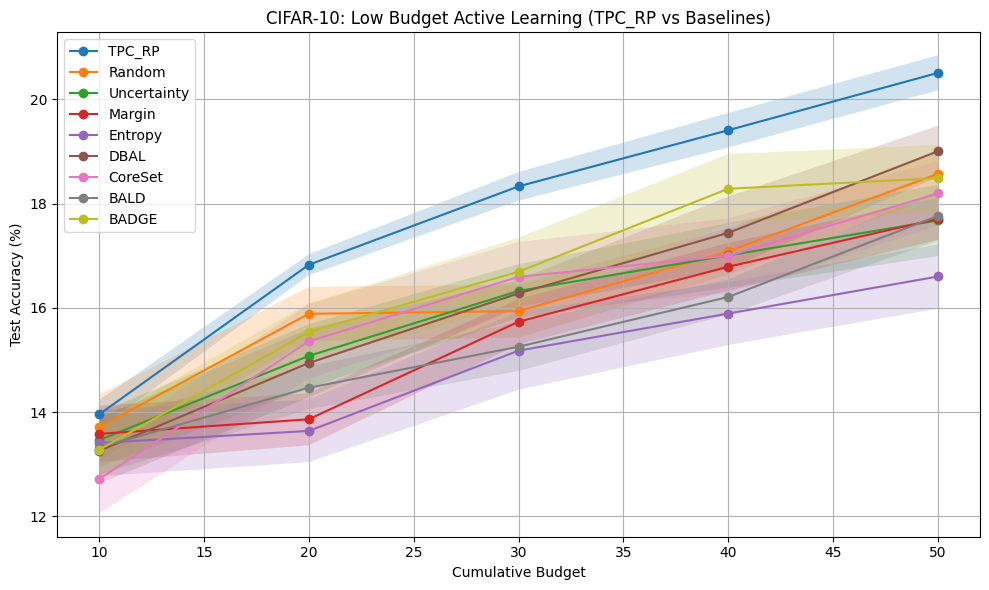

In [ ]:
budgets = [B * (i + 1) for i in range(num_rounds)]

plt.figure(figsize=(10, 6))
for name, accuracy in all_accuracies.items():
    accuracies = np.array(accuracy)
    means = accuracies.mean(axis=0) * 100
    stderrs = accuracies.std(axis=0) / np.sqrt(num_repetitions) * 100
    plt.plot(budgets, means, marker="o", label=name)
    plt.fill_between(budgets, means - stderrs, means + stderrs, alpha=0.2)

plt.xlabel("Cumulative Budget")
plt.ylabel("Test Accuracy (%)")
plt.title("CIFAR-10: Low Budget Active Learning (TPC_RP vs Baselines)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("al_results.png", dpi=150, bbox_inches="tight")
plt.show()